In this Jupyter notebook, I define the functions necessary for simulating the quantum circuit of the tranverse field Ising model. I will start with methods used in this IBM tutorial ([https://quantum.cloud.ibm.com/docs/en/tutorials/transverse-field-ising-model](https://quantum.cloud.ibm.com/docs/en/tutorials/transverse-field-ising-model)) which claims to be an efficient way to Trotterize the TFI model.

In [59]:
import numpy as np
from numpy.linalg import matrix_power
from numpy.linalg import eigh
from scipy.special import factorial
from scipy.sparse.linalg import expm_multiply
import functools as ft


from qiskit import QuantumCircuit,  QuantumRegister, ClassicalRegister, AncillaRegister, transpile
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate, hamiltonian_variational_ansatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.synthesis import SuzukiTrotter
from qiskit.primitives import BackendEstimatorV2 as Estimator


from qiskit_aer import AerSimulator

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA, SPSA, GradientDescent, NFT, ADAM, CG

import os
import csv
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as tck


Generate the Hamiltonian operator $H = - \sum_i J Z_i Z_{i+1} - h X_i$ for an $N$ qubit chain.

In [60]:
def ham_couple(qc, J, PBC = True):
    ''' Generates the site-site coupling part of the Hamiltonian and returns a SparsePauliOp'''
    chain_len = qc.num_qubits - qc.num_ancillas
    num_ancillas = qc.num_ancillas
    pauli_string = 'ZZ' + 'I' * (chain_len -2)

    #control for periodic boundaries
    if PBC: BC = 0
    else: BC = 1
    
    ops_list = [("I" * num_ancillas + pauli_string[-shift:]+ pauli_string[:-shift]  , -1.0 *J) for shift in range(chain_len - BC)]
    ham = SparsePauliOp.from_list(ops_list)
    return ham

def ham_zeeman(qc, h):
    ''' Generates the coupling to the external field and returns a SparsePauliOp'''
    chain_len = qc.num_qubits - qc.num_ancillas
    num_ancillas = qc.num_ancillas
    pauli_string = 'X' + 'I' * (chain_len -1)
    
    
    ops_list = [("I" * num_ancillas + pauli_string[shift:] + pauli_string[:shift] , -1.0 *h) for shift in range(chain_len)]
    ham = SparsePauliOp.from_list(ops_list)
    return ham

def Hamiltonian(qc, J, h, PBC = True):
    '''Generates the full Hamiltonian as a SparsePauliOp'''
    return ham_couple(qc, J, PBC = PBC) + ham_zeeman(qc, h)


Initialize the Quantum circuit with a qubit, ancilla, and classical register

In [61]:

def circuit_initialize(num_qubits, num_ancilla, num_classical):
    '''Builds a circuit appropriate for a num_qubit Ising chain.'''
    
    state_qubits = QuantumRegister(num_qubits, "s")
    ancilla_qubits = AncillaRegister(num_ancilla, "a")
    classical_bits = ClassicalRegister(num_classical, "c")
    qc = QuantumCircuit(state_qubits , ancilla_qubits, classical_bits)
    return qc

Time evolution is to be Trotterized by a second order operation: $\exp(A + B) \approx \exp(A/2) \exp(B)\exp(A/2)$. The time step will be controlled by the delta parameter which must be optimized to ensure time evolution is accurate while maintaining a reasonable number of gates. 

In [62]:
def trotter_evolve(qc, time_end, delta, J, h, PBC = True):
    '''appends to a quantum circuit the time evolution by Trotterized exponential Hamiltonian '''

    chain_len = qc.num_qubits - qc.num_ancillas
    if time_end/delta % 1 != 0:
        extra_time = time_end - delta * int(time_end/delta)
    else: 
        extra_time = 0

    for i in range(chain_len):
        qc.rx(-1.0 * h * delta/2, i)
    for t in np.arange(0, time_end - delta , delta):
        for i in range(chain_len ):
            if PBC or i != chain_len -1:
                qc.rzz(-1.0 * J * delta, i, (i+1) % chain_len)
            qc.rx(-1.0 * h * delta, i)

    for i in range(chain_len):
        if PBC or i != chain_len -1:
                qc.rzz(-1.0 * J * delta, i, (i+1) % chain_len)
        qc.rx(-1.0 * h * delta/2, i)

    if extra_time > 0:
        for i in range(chain_len):
            qc.rx(-1.0 * h * extra_time/2, i)
        for i in range(chain_len ):
            if PBC or i != chain_len -1:
                qc.rzz(-1.0 * J * delta, i, (i+1) % chain_len)
            qc.rx(-1.0 * h * extra_time, i)

        for i in range(chain_len):
            if PBC or i != chain_len -1:
                qc.rzz(-1.0 * J * delta, i, (i+1) % chain_len)
            qc.rx(-1.0 * h * extra_time/2, i)

            


def trotter_evolve_PauliEvolutionGate(qc, time_end, J, h, order = 2, reps = 2, PBC = True):
    """Uses built in function to Trotterize (for comparison with manual Trotterization)"""

    num_qubits = qc.num_qubits                  # divind h and J by 2 because the built in function multiplies the Hamiltonian by 2 for some reason, so this is a workaround to get the same evolution as the manual Trotterization
    qc.append(PauliEvolutionGate(Hamiltonian(qc, J/2, h/2, PBC = PBC), time_end , 
                                     synthesis=SuzukiTrotter(order , reps ), label = "$\\exp\\{- i H (t)\\}") , range(num_qubits))




Construct measurements: 1) spin Z on a single site, 2) prduct of spin X on all even sites

In [ ]:
def spin_Z_measure(qc, register_bit):
    '''measures spin in z basis of site'''
    for reg in qc.qregs:  #Define the ancilla register
        if reg.name == "a":
            ancilla_qubits = reg
            break
    
    for reg in qc.cregs:    #Define the classical register
        if reg.name == "c":
            classical_bits = reg
            break

    qc.measure((qc.num_qubits - qc.num_ancillas)//2, classical_bits[register_bit])

def spin_X_even_measure(qc, register_bit):
    '''measures the total of the spins in x basis of just even sites'''
    for reg in qc.qregs:  #Define the ancilla register
        if reg.name == "a":
            ancilla_qubits = reg
            break
    
    for reg in qc.cregs:    #Define the classical register
        if reg.name == "c":
            classical_bits = reg
            break

    num_qubits = qc.num_qubits - qc.num_ancillas

    for i in range(0, num_qubits, 2):           #rotate qubit into x basis, CNOT to ancilla, rotate back
        qc.h(i)
        qc.cx(i, ancilla_qubits[register_bit])
        qc.h(i)

    qc.measure(ancilla_qubits[register_bit], classical_bits[register_bit])

Now construct the whole circuit.

In [64]:
def ising_correlation_circuit(qc,  J, h, time_end, delta, measure , evolution = "manual", order = 2, PBC = True):
    '''constructs circuit which measures 'measure' at the start, and then at the end and reads into clbits'''

    if measure == 'Z':
        spin_Z_measure(qc, 0)
    elif measure == 'X_even':
        spin_X_even_measure(qc, 0)
    else:
        raise ValueError("measure must be either 'Z' or 'X_even'")

    if evolution == "manual":
        trotter_evolve(qc, time_end, delta, J, h, PBC = PBC)
    elif evolution == "PauliEvolutionGate":
        if time_end/delta % 1 != 0:
            raise ValueError("time_end is not an integer multiple of delta.")
        trotter_evolve_PauliEvolutionGate(qc, time_end, J, h, order = order, reps = int(time_end/delta), PBC = PBC)

    if measure == 'Z':
        spin_Z_measure(qc, 1)
    elif measure == 'X_even':
        spin_X_even_measure(qc, 1)
    

We first need to run on a simulator to optimize the Trotter evolution delta parameter, and to make sure the LG bound is violated. We will first choose to measure the single site $Z$ operator. It's worth noting that the Abboud, Bradlyn paper claims that at any finite time, and for any finite $h$ in the ordered phase $J > h$ that the LG bound is immediately violated. Because we don't have access to the exact ground state for any $h, J \neq 0$ without constructing a variational ansatz, we will approximate the ground states in the limit with either a polarized set of qubits in the z or x basis (for the $J/h \gg 1$ and $h/J \gg 1$ limits respectively). After confirming our calculations, we will construct the ansatz wavefunction. 

In [65]:
#First the h/J >> 1 limit

C = []
time_end = 0.5
for j in range(1,3):

    chain_len = 4
    qc = circuit_initialize(chain_len, 2, 2)
    num_shots = 10000

    #ground state is all spins in the positive x direction, so we can prepare it by applying H to all qubits
    for i in range(chain_len):
        qc.h(i)

    ising_correlation_circuit(qc, J = 1, h = 10, time_end = time_end * j, delta = 0.05, measure = 'Z')
    backend = AerSimulator()
    job = backend.run(qc, shots = num_shots)
    counts = job.result().get_counts()
    C.append((counts["00"]+ counts["11"] - counts["01"] - counts["10"]) / num_shots)


    #Calculate the correlation from the counts

print( "simulated K value: " + str(2 *C[0] - C[1]))

simulated K value: 1.1446


We will need an efficient way to construct the ground state. We will use a Hamiltonian variational approach.

In [66]:
def TFI_HVA_ansatz(qc, layers, x_pol_Bool = False, PBC = True):
    '''Builds a TFI HVA ansatz with the given number of layers and parameters J and h'''

    chain_len = qc.num_qubits - qc.num_ancillas
    params = []

    if x_pol_Bool:                   #If we are in the paramagnetic phase, we can construct a zeroth order approximation to the gs by converting to the x polarized state
        for i in range(chain_len):
            qc.h(i)
        
    for l in range(layers):        
        epsilon =Parameter(f'epsilon_{l}')
        for i in range(chain_len):
            if PBC or i != chain_len -1:
                qc.rzz(2*(epsilon), i, (i+1) % chain_len)
        params.append(epsilon)

        # Apply e^{-iφ H_X} = Π R_x(2hφ)
        beta =Parameter(f'beta_{l}')
        for i in range(chain_len):
            qc.rx(2*(beta), i)
        params.append(beta)

        
        for i in range(chain_len):
            if PBC or i != chain_len -1:
                qc.crx(2*(gamma :=Parameter(f'gamma_{l}_{i}')), i, (i+1) % chain_len)
        params.append(gamma)
    
    return qc, params


def run_tfim_vqe(qc, J, h, layers = 1 , model= "HVA", optimizer = COBYLA(maxiter=300), PBC = True):
    """VQE for TFIM"""
    
    # Create Hamiltonian
    hamiltonian = Hamiltonian(qc, J, h, PBC = PBC)

    x_pol_Bool = h > J * 1.2  # Determine if we are in the paramagnetic phase for HVA ansatz initialization
    

    if model == "HVA":
        ansatz, params = TFI_HVA_ansatz(qc, layers , x_pol_Bool, PBC = PBC)
        initial_point = [0.0] * len(ansatz.parameters)
    elif model =="HVA_Qis":
        ansatz = hamiltonian_variational_ansatz(hamiltonian, reps=layers, PBC = PBC)
        initial_point = [0.0] * len(ansatz.parameters)
        if x_pol_Bool:
            qc_hadamard = QuantumCircuit(qc.num_qubits)
            for i in range(qc.num_qubits):
                qc_hadamard.h(i)

            ansatz = qc_hadamard.compose( ansatz)
            

    # Initialize VQE
    backend = AerSimulator()
    estimator = Estimator(backend=backend)
    vqe = VQE(estimator, ansatz, optimizer, initial_point=initial_point)
    
    # Run VQE
    result = vqe.compute_minimum_eigenvalue(operator=hamiltonian)
    
    return result.optimal_value, result.optimal_parameters, ansatz.assign_parameters(result.optimal_parameters)




Now we will construct an efficient circuit for simulation purposes to determine the most efficient range of parameter bounds. This simulation will include noise inherent to the quantum hardware.

In [67]:


def TFI_efficient_sim(qc, t_end, delta, J, h, measure, shots = 10000, PBC = True ):
    """Efficiently runs the simulation for the TFI model and returns the correlation of 'measure' by saving the statevector at every delta time step."""
     
    chain_len = qc.num_qubits - qc.num_ancillas
    num_steps =int(t_end/delta) +1                    #The trotter steps for the second trotterized function must be globally defined
    all_counts = []

    for reg in qc.qregs:  #Define the ancilla register
        if reg.name == "a":
            ancilla_qubits = reg
            break
    
    for reg in qc.cregs:    #Define the classical register
        if reg.name == "c":
            classical_bits = reg
            break

    if measure == 'Z':
        qc.cx(0, ancilla_qubits[0])
    elif measure == 'X_even':
        for i in range(0, chain_len, 2):           #rotate qubit into x basis, CNOT to ancilla, rotate back
            qc.h(i)
            qc.cx(i, ancilla_qubits[0])
            qc.h(i)
    else:
        raise ValueError("measure must be either 'Z' or 'X_even'")

    qc.save_statevector()                        #First leg of the circuit

    backend = AerSimulator(method = "statevector") #run the initial circuit
    qc = transpile(qc, backend)                
    job = backend.run(qc, shots = 1)           #only one shot is needed to save the statevector     
    result = job.result()                       

        #do a loop over time values where we:
    #1) extract the statevector from the result of the previous circuit
    #2) copy the statevector
    #3) measure the copy
    #4) evolve the original statevector by another time step

    for step in range( num_steps):
        state = result.get_statevector()                 #Extract the statevector from the result of the previous circuit
        qc1 = circuit_initialize(chain_len, 2,2)
        qc1.initialize(state, range(chain_len+2))
        if measure == 'Z':
            qc1.cx(0, ancilla_qubits[1])
        elif measure == 'X_even':
            for i in range(0, chain_len, 2):           #rotate qubit into x basis, CNOT to ancilla, rotate back
                qc1.h(i)
                qc1.cx(i, ancilla_qubits[1])
                qc1.h(i)
        qc1.measure(ancilla_qubits, classical_bits)

        qc1 = transpile(qc1, backend) 
        job1 = backend.run(qc1, shots = shots)
        result1 = job1.result().get_counts()
        correlator =  (result1.get("00",0)+ result1.get("11",0) - result1.get("01",0) - result1.get("10",0)) / shots
        all_counts.append(correlator)

        qc = circuit_initialize(chain_len, 2, 2)
        qc.initialize(state, range(chain_len+2))
        trotter_evolve(qc, delta, delta, J, h, PBC = PBC)     #evolve original state by time step
        qc.save_statevector() 

        qc = transpile(qc, backend)
        job2 = backend.run(qc, shots = 1)           #only one shot is needed to save the statevector
        result = job2.result()

    return all_counts


def TFI_PauliEvolution_sim(qc, t_end, J, h, measure ,  order = 2, num_shots = 10000, reps = 2,  evolution = "manual", psi = "GS", layers = 10, model = "HVA_Qis", PBC = True):
    """Efficiently runs the simulation for the TFI model using the built in PauliEvolutionGate and returns the correlation of 'measure' at the final time."""
     
    chain_len = qc.num_qubits - qc.num_ancillas        #The trotter steps for the second trotterized function must be globally defined              
    delta = t_end / reps

    for reg in qc.qregs:  #Define the ancilla register
        if reg.name == "a":
            ancilla_qubits = reg
            break
    
    for reg in qc.cregs:    #Define the classical register
        if reg.name == "c":
            classical_bits = reg
            break


    if psi == "GS":
        energy, params, qc = run_tfim_vqe(qc, J, h, layers = layers , model= model, PBC = PBC)
    elif psi == "X_pol":
        for i in range(chain_len):
            qc.h(i)
        
    #construct the circuit
    ising_correlation_circuit(qc,  J, h, t_end, delta, measure , evolution = evolution, order = order, PBC = PBC)

    #run simulation
    backend = AerSimulator()
    qc = transpile(qc, backend)
    job = backend.run(qc, shots = num_shots)
    counts = job.result().get_counts()
    qc = transpile(qc, basis_gates=['rx', 'ry', 'rz', 'cz'], optimization_level=3)

    return qc, qc.size(), (counts.get("00", 0) + counts.get("11", 0) - counts.get("01", 0) - counts.get("10", 0)) / num_shots



We can also directly compute the bound set by the Quantum Fisher Information for small system sizes.

In [68]:
def Quantum_Fisher(state, Ham, Qop):
    '''calculates the Quantum Fisher information with respect to an operator Q given the state in the Hlbert space, the Hamiltonian, and the operator Q'''

    psi = state
    eig_values, eig_vectors = eigh(Ham)

    Qop =  Qop.to_matrix(sparse = False)  #turn into dense matrix

    QFI = 0
    for e in eig_vectors[1:]:
        psim = Qop @ e
        QFI += 4 * (np.abs(psim.dot(psi))) **2

    return QFI

The below generates data and exports to a csv file in "/data/"

In [80]:
chain_len , time , delta, J, h, measure, psi, layers, PBC = 8, 2, .05, 1, .1, 'X_even', "GS", 20, False


time_range = [i * delta for i in range(int(time/delta)+1)]

layer = ''
if psi == "GS":
    layer = "layers" + str(layers)

qc = circuit_initialize(chain_len, 2, 2)
if psi == "X_pol":
    for i in range(chain_len):  #initialize ground state in x basis (large magnetic field)
        qc.h(i)
elif psi == 'GS':
    energy, params, qc = run_tfim_vqe(qc, J, h, layers = layers , model= "HVA", PBC = PBC)
qcTrot = qc.copy("qcTrot")

C_data = TFI_efficient_sim(qc, time, delta, J, h, measure, shots = 500000, PBC = PBC)


csv_path = os.getcwd() + "/data/" + "L"+str(chain_len) + 'time'+ str(time) + 'd' + str( delta)+ "J" + str(J) + "h" + str(h) +str(measure) + "psi" + psi + layer +'PBC' + str(PBC) + '.csv'

rows = [time_range, C_data]
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(rows)

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT/data/L8time2d0.05J1h1X_evenpsiGSlayers20PBCFalse.csv'

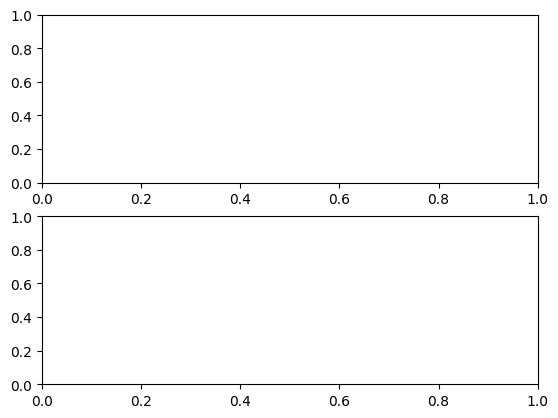

In [72]:

plt_dta = [  [8, 2, .05, 1, 1, 'X_even', "GS", 20, False]]

fig, ax = plt.subplots(2)

for i in plt_dta:
    chain_len , time , delta, J, h, measure, psi , layers, PBC = i 
    layer = ''
    if psi == "GS":
        layer = "layers" + str(layers)
    csv_path = os.getcwd() + "/data/" + "L"+str(chain_len) + 'time'+ str(time) + 'd' + str( delta)+ "J" + str(J) + "h" + str(h) +str(measure) + "psi" + psi + layer +'PBC' + str(PBC) + '.csv'


    with open(csv_path, newline='') as f:
        reader = csv.reader(f)
        [time_range, dta] = [[float(x) for x in row] for row in reader]
    
    half_len = len(dta)//2
    dta_K = [2 * dta[j] - dta[2 * j] for j in range(half_len) ]

    ax[1].scatter(time_range[:half_len]  , dta_K ,  marker= ".", label = "$\\delta_t = $" + str(delta)   , zorder = 3)
    ax[0].scatter(time_range  , dta ,  marker= ".", label = "N = " + str(chain_len) + ", $\\delta_t$ = " + str(delta) , zorder = 3)


#classical bound
#ax[1].axhline( y=1.5, color="0.9", linestyle = "--")
#ax[1].axhline( y=QFI_bound, color="0.9", linestyle = "--", label = "$1/8(F_Q) + \\langle (S^z_0 e^{i \\pi S^z_1}S^z_2)^2\\rangle$")


fig.suptitle("")
ax[0].xaxis.set_major_locator(tck.MultipleLocator(base = .5))
ax[1].xaxis.set_major_locator(tck.MultipleLocator(base = .1))
plt.xlabel("time")
ax[0].set(ylabel = "C(t)")
ax[1].set(ylabel = "K(t) = 2C(t) - C(2t)")
#plt.ylim((0.9,1.6))
plt.title("")
plt.legend()

plt.show()

In [ ]:
#Save plot
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\TFIM_HVA_Layer_Eigenstate_Compare_h1.5.png")

We will now look at the cost of these calculations on actual quantum Hardware. Firstly, generating the ground state through the VQE will cost more in depth depending on how many layers we add. Therefore, it is worthwhile to calculate how the accuracy of the ansatz depends on the layers for exactly calculable system sizes. 

In [ ]:
def variational_error(chain_len=4, J=0.1, h=1, layers=2, model = "HVA", optimizer = SPSA(maxiter = 200)):
    """Calculate the variational error for the TFI model. Outputs tuple of (1 - overlap with true ground state, relative energy error)"""

    qc_temp = circuit_initialize(chain_len, 0, 0)
    Ham = Hamiltonian(qc_temp, J, h).to_matrix(sparse = False)
    eig_values, eig_vectors = eigh(Ham )            #convert Hamiltonian do dense matrix

    E0, params, qc_var = run_tfim_vqe(qc_temp, J=J, h=h, layers=layers, model = model, optimizer = optimizer)
    var_state = Statevector(qc_var)                 #generate variational energy and state
    if J > h:
        overlap1 = np.abs(var_state.data.dot(eig_vectors[0])) **2   #ground state becomes degenerate
        overlap2 = np.abs(var_state.data.dot(eig_vectors[1])) **2
        overlap = overlap1 + overlap2
    else:
        overlap =  np.abs(var_state.data.dot(eig_vectors[0])) **2   #calculate overlap with true ground state
    energy_error = np.abs((E0 - eig_values[0]) / eig_values[0])    #calculate energy error

    return 1 - overlap, energy_error


Here we test the accuracy of the variational ansatz

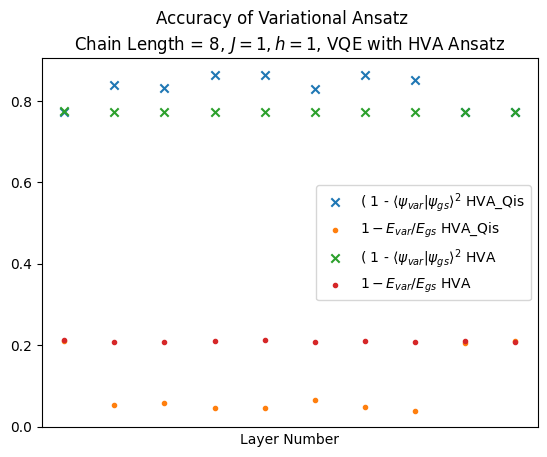

: 

In [ ]:


fig, ax = plt.subplots(1)

h = 1
J = 1

layer_end = 20

d_state_list = []
d_energy_list = []
d_state_list2 = []
d_energy_list2 = []
layer_list = range(1,(layer_end+1)*1, 2 )
for i in layer_list:
    d_state, d_energy = variational_error(chain_len = 8, J = J, h = h, layers = i, model = "HVA_Qis", optimizer = COBYLA(maxiter = 300))
    d_state_list.append(d_state)
    d_energy_list.append(d_energy)
    d_state2, d_energy2 = variational_error(chain_len = 8, J = J, h = h, layers = i, model = "HVA", optimizer = COBYLA(maxiter = 300))
    d_state_list2.append(d_state2)
    d_energy_list2.append(d_energy2)

ax.scatter(layer_list  , d_state_list ,  marker= "x", label = "( 1 - $\\langle \\psi_{var} | \\psi_{gs} \\rangle^2$ HVA_Qis", zorder = 3)
ax.scatter(layer_list  , d_energy_list ,  marker= ".", label = "$1 - E_{var}/E_{gs}$ HVA_Qis" , zorder = 3)

ax.scatter(layer_list  , d_state_list2 ,  marker= "x", label = "( 1 - $\\langle \\psi_{var} | \\psi_{gs} \\rangle^2$ HVA", zorder = 3)
ax.scatter(layer_list  , d_energy_list2 ,  marker= ".", label = "$1 - E_{var}/E_{gs}$ HVA" , zorder = 3)


fig.suptitle("Accuracy of Variational Ansatz")
ax.xaxis.set_major_locator(tck.MultipleLocator(base = 100))
plt.xlabel("Layer Number")
ax.set(ylabel = "")
plt.title("Chain Length = 8, $J = $" + str(J) + "$, h =$" + str(h) +", VQE with HVA Ansatz")
plt.legend()

plt.show()

In [ ]:
qc = QuantumCircuit(8)
E0, params, qc_var = run_tfim_vqe(qc, J=1, h=1, layers= 2, model = "HVA", optimizer = COBYLA(maxiter = 300))
#qc_var.draw(output = "mpl")

We will generate a plot which compares a range of $J$ and $h$ values with the errors in the variational state and the layer.

In [ ]:
chain_len, layers, num_steps= 8, 4, 10

#We will generate a sweep of J and h where J = sin(theta) and h = cos(theta)
theta_range = [i * np.pi  for i in np.arange(0.5/(num_steps+1), 0.5 - 0.5/(num_steps+1), 0.5/ (num_steps+2))]

d_state_list = []
d_energy_list =[]
for theta in theta_range:
    J = np.sin(theta)
    h = np.cos(theta)
    d_state, d_energy =variational_error(chain_len = chain_len, J = J, h = h, layers = layers, model = "HVA_Qis", optimizer = COBYLA(maxiter = 300))
    d_state_list.append(d_state)
    d_energy_list.append(d_energy)

csv_path = os.getcwd() + "/data/" + "L"+str(chain_len) +"layers" +str(layers) + "steps" + str(num_steps) +'.csv'

rows = [theta_range, d_state_list, d_energy_list]
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(rows)

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ianro\AppData\Local\Temp\ipykernel_27456\3360446546.py:23: SyntaxWarning: invalid escape sequence '\s'
  plt.title("$J = \sin\\theta, h = \cos\\theta$")


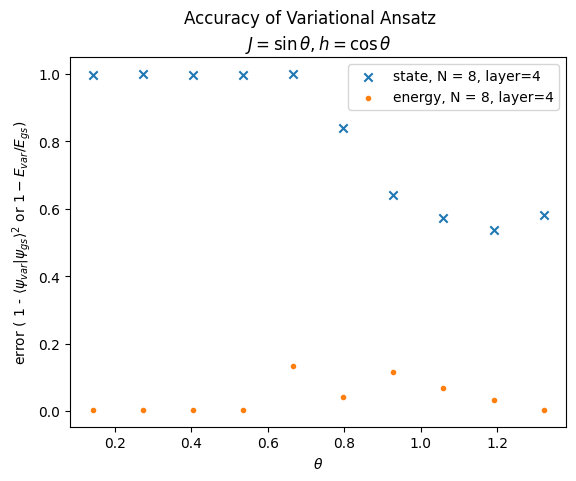

In [ ]:

plt_dta = [[8,4,10]]

fig, ax = plt.subplots(1)

for i in plt_dta:
    chain_len, layers, num_steps = i 
    csv_path = os.getcwd() + "/data/" + "L"+str(chain_len) +"layers" +str(layers) + "steps" + str(num_steps) +'.csv'

    with open(csv_path, newline='') as f:
        reader = csv.reader(f)
        [theta_range, d_state, d_energy] = [[float(x) for x in row] for row in reader]
    

    ax.scatter(theta_range  , d_state ,  marker= "x", label = "state, N = " + str(chain_len) + ", layer=" + str(layers), zorder = 3)
    ax.scatter(theta_range  , d_energy ,  marker= ".", label = "energy, N = " + str(chain_len) + ", layer=" + str(layers) , zorder = 3)
    


fig.suptitle("Accuracy of Variational Ansatz")
#ax.xaxis.set_major_locator(tck.MultipleLocator(base = 2.5))
plt.xlabel("$\\theta$")
ax.set(ylabel = "error ( 1 - $\\langle \\psi_{var} | \\psi_{gs} \\rangle^2$ or $1 - E_{var}/E_{gs}$)")
plt.title("$J = \sin\\theta, h = \cos\\theta$")
plt.legend()

plt.show()

Now to see the cost in terms of gates

In [ ]:
def ops_depth_count(chain_len, num_steps, layers, measure, circuit_element = "All"):
    '''Counts the number of gates and depth of the circuit for a given chain length, time step, number of layers, and measurement choice'''

    J = 1       #arbitrary Hamiltonain values
    h = 1
    delta = 1

    qc = circuit_initialize(chain_len, 2, 2)    # initialize circuit

    if circuit_element =="All" or circuit_element == "Ansatz":
        TFI_HVA_ansatz(qc, layers, False )                 #build the vairational ansatz
    if circuit_element =="All" or circuit_element == "Evolve":
        ising_correlation_circuit(qc,  J, h, delta * num_steps, delta, measure , evolution = "PauliEvolutionGate", order = 4)
                                                #build the circuit

    return qc.count_ops(), qc.size(), qc.depth()

C:\Users\ianro\AppData\Local\Temp\ipykernel_20044\3697751169.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


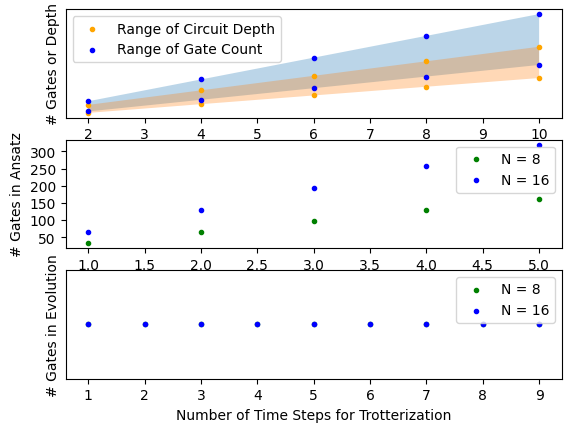

In [ ]:
ops_list_min = []
ops_list_max = []
depth_list_min = []
depth_list_max = []
time_end = 3
J = 1
h= 1
chain_len_max = 10

x = range(2, chain_len_max + 1, 2) 

for i in x:
    chain_len, delta_max, delta_min,  measure_max, measure_min= i, .1/ (np.sqrt(i)),  1,  'X_even', 'Z'
    psi_max, psi_min, layers_min, layers_max =  'X_pol', 'Z_pol', 2, 3

    ops_max, size_max, depth_max = ops_depth_count(chain_len, int(time_end/delta_max)+1, layers_max, measure_max, "All")
    ops_min, size_min, depth_min = ops_depth_count(chain_len, int(time_end/delta_min)+1, layers_min, measure_min, "All")

    depth_list_min.append(depth_min)
    ops_list_min.append(size_min)
    depth_list_max.append(depth_max)
    ops_list_max.append(size_max)

ops_list_max = np.array(ops_list_max)
ops_list_min = np.array(ops_list_min) 


ansatz_size_8 = [ops_depth_count(8, 1, i, measure_min, "Ansatz")[1] for i in range(1,6)]
ansatz_size_16 = [ops_depth_count(16, 1, i, measure_min, "Ansatz")[1] for i in range(1,6)]

evolution_size_8 = [ops_depth_count(8, 1, 1, measure_min, "Evolve")[1] for i in range(1,10)]
evolution_size_16 = [ops_depth_count(16, i , 1, measure_min, "Evolve")[1] for i in range(1,10)]

fig, ax = plt.subplots(3)
ax[0].scatter(x, depth_list_max, marker=".",  zorder=3, color="orange")
ax[0].scatter(x, depth_list_min, marker=".", label="Range of Circuit Depth" , zorder=3, color="orange")
ax[0].scatter(x, ops_list_max, marker=".",  zorder=3, color="blue")
ax[0].scatter(x, ops_list_min, marker=".", label="Range of Gate Count" , zorder=3, color="blue")

ax[0].legend()
ax[0].set(ylabel = "# Gates or Depth")
ax[0].set_xlabel("Chain Length(logical qubits - 2)")
ax[0].fill_between(x, ops_list_max, ops_list_min, alpha = 0.3)
ax[0].fill_between(x, depth_list_max, depth_list_min, alpha = 0.3)
ax[0].yaxis.set_major_locator(tck.MultipleLocator(base = 400))

ax[1].scatter(range(1,6), ansatz_size_8, marker=".", label="N = 8", zorder=3, color="green")
ax[1].scatter(range(1,6), ansatz_size_16, marker=".", label="N = 16", zorder=3, color="blue")
ax[1].set(ylabel = "# Gates in Ansatz")
ax[1].set_xlabel("Ansatz Layer Count")
ax[1].yaxis.set_major_locator(tck.MultipleLocator(base = 50))
ax[1].legend()

ax[2].scatter(range(1,10), evolution_size_8, marker=".", label="N = 8", zorder=3, color="green")
ax[2].scatter(range(1,10), evolution_size_16, marker=".", label="N = 16", zorder=3, color="blue")
ax[2].set(ylabel = "# Gates in Evolution")
ax[2].set_xlabel("Number of Time Steps for Trotterization")
ax[2].yaxis.set_major_locator(tck.MultipleLocator(base = 50))
ax[2].legend()
fig.show()

In [ ]:
#Save plot
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\TFIM_HVA_Layer_Eigenstate_Compare_h1.5.png")

In [ ]:
ops, size, depth =ops_depth_count(chain_len =8, num_steps =10, layers =2, measure = 'Z')
print("The operations in the circuit are: " + str(ops))
print("The size of the circuit is: " + str(size))
print("The depth of the circuit is: " + str(depth))

The operations in the circuit are: OrderedDict({'rx': 104, 'rzz': 80, 'cx': 32, 'rz': 16, 'measure': 2})
The size of the circuit is: 234
The depth of the circuit is: 133


We can plot different ways of evolving the Hamiltonian. Increasing the order of the Suzuki-Trotter decomposition should decrease the number of Trotter steps necessary to arrive at a reasonable approximation  of the Correlation function $C(t)$.

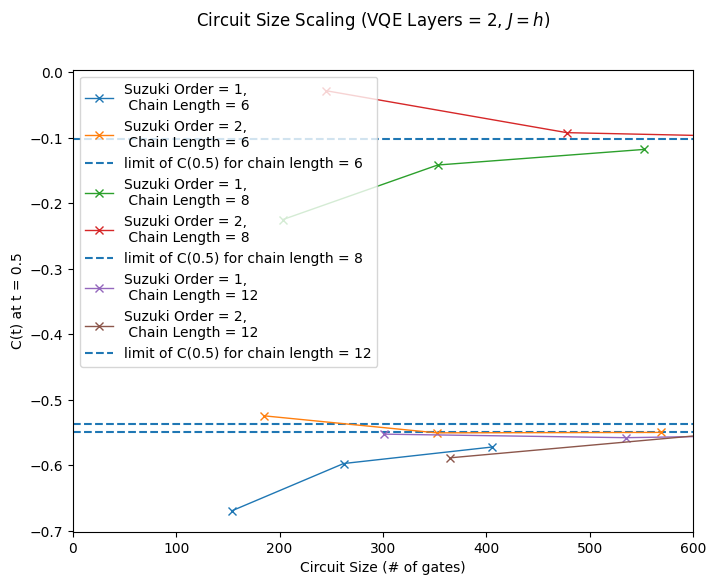

In [ ]:
num_shots = 100000
time_end = 0.5
J = 1
h = 1
measure = "X_even"
psi = "GS"
chain_len = 8
order_list = [1, 2]

fig, ax = plt.figure(figsize = (8,6)), plt.subplot()

for layers in [4, 10, 20]:

    qc = circuit_initialize(chain_len, 2, 2)    
    energy, params, qc = run_tfim_vqe(qc, J, h, layers = layers , model= "HVA")

    for order in order_list:
        size_list = []
        C_list = []
        for reps in [1,  4, 8]:
            qc_copy = qc.copy("qc_copy")
            qc_temp, size, C_t = TFI_PauliEvolution_sim(qc_copy, time_end, J, h, measure ,  order = order, num_shots = num_shots, reps = reps, evolution = "PauliEvolutionGate")
            if size > 1000:
                break
            size_list.append(size)
            C_list.append(C_t)
            
        if len(size_list) > 0:
            ax.plot(size_list  , C_list , marker = "x",  label = "Suzuki Order = " + str(order)+ ",\n Chain Length = " + str(chain_len), zorder = 3, linestyle = "-", linewidth=1)

    ax.axhline( y=C_list[-1],linestyle = "--", label = "limit of C(0.5) for chain length = " + str(chain_len)) 



fig.suptitle("Circuit Size Scaling (VQE Layers = 2, $J = h$)")
#ax.xaxis.set_major_locator(tck.MultipleLocator(base = 2.5))
plt.xlabel("Circuit Size (# of gates)")
ax.set(ylabel = "C(t) at t = " + str(time_end))
ax.set_xlim(0,600)
#plt.title("VQE layer = 2")
plt.legend()

plt.show()

In [ ]:
#Save plot
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\TFIM_Resources_chain_len.png")

131
131


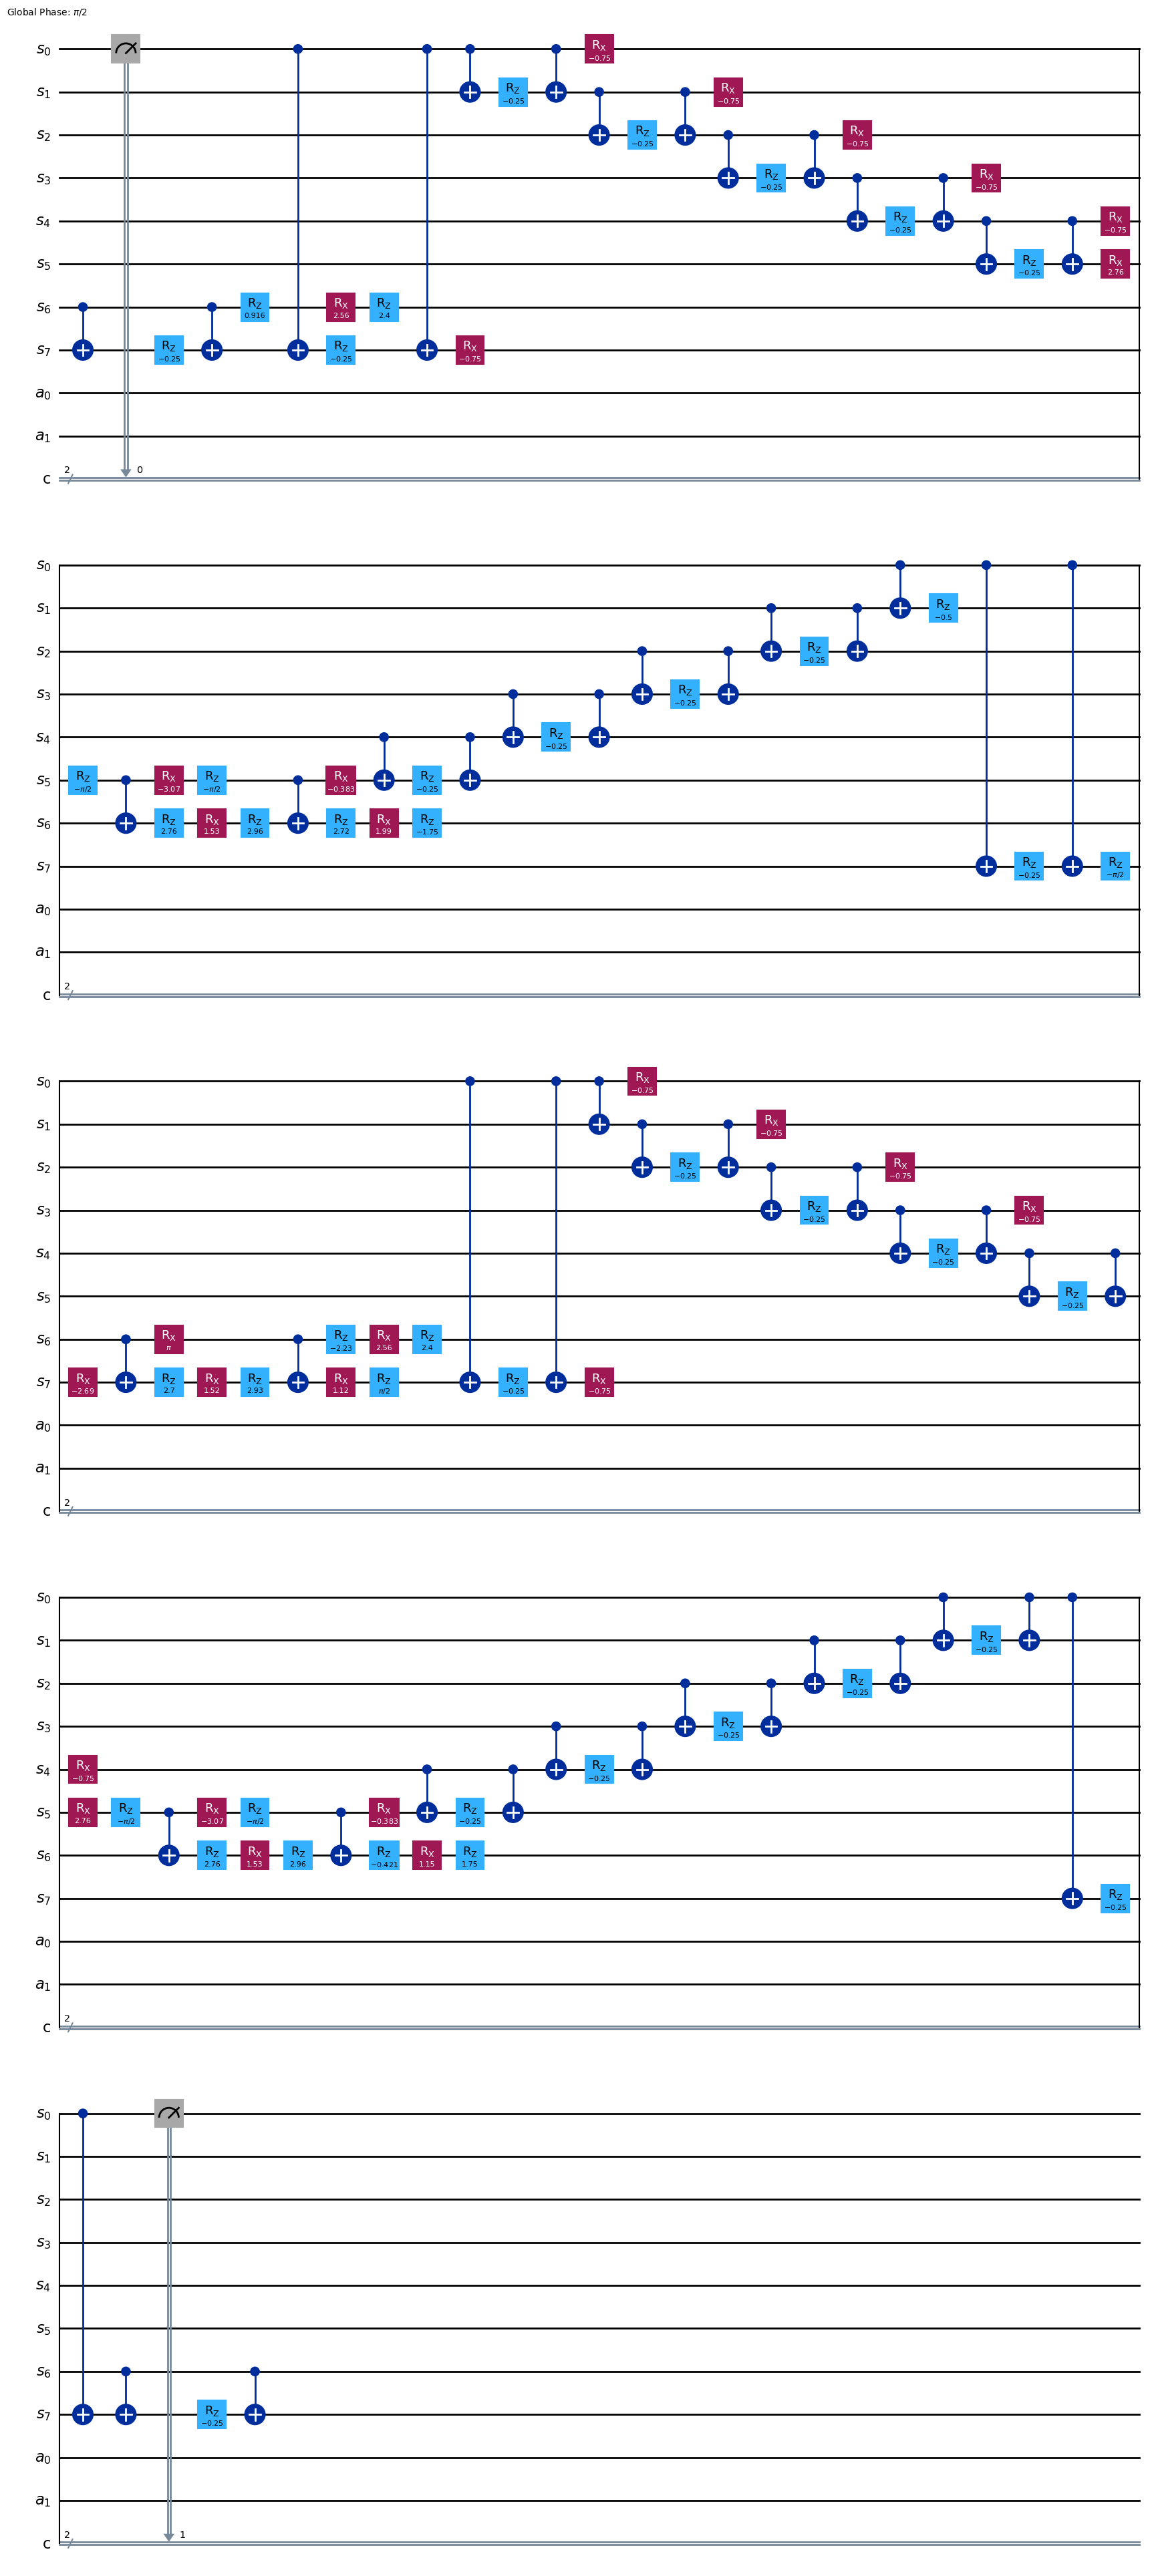

In [ ]:
qc = circuit_initialize(8, 2, 2) 
qc, size, C_t = TFI_PauliEvolution_sim(qc, 1, 1, 1.5, "Z" ,  order = 2, num_shots = 10, reps = 2, evolution = "PauliEvolutionGate") 
print(qc.size())
qc.draw(output = "mpl")